In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2dvbnphbG92aWRhbC9Eb2N1bWVudHMvR2l0SHViL1B5dGhvbl9mb3JfU3ludGhldGljX0Jpb2xvZ3kvY2hhcHRlcnM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/importlib/_bootstrap.py": 1749130019.08049, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/importlib/_bootstrap_external.py": 1749130019.092533, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/zipimport.py": 1749130014.228809, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/codecs.py": 1749130012.791808, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/aliases.py": 1749130016.218093, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/__init__.py": 1749130016.206209, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/encodings/utf_8.py": 1749130017.621478, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/abc.py": 1749130012.596308, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/io.py": 1749130013.2025, "/Users/gonzalovidal/opt/anaconda3/envs/psb/lib/python3.11/stat.py": 1749130013.847848, "/Users/gonzalovidal/opt/anaconda3/envs

In [2]:
import pandas as pd

edge_table = pd.DataFrame(
    [
        {"source": "AraC", "target": "pBAD", "interaction": "activation", "sign": 1},
        {"source": "pBAD", "target": "GFP", "interaction": "expression", "sign": 1},
        {"source": "LacI", "target": "pLac", "interaction": "repression", "sign": -1},
        {"source": "pLac", "target": "RFP", "interaction": "expression", "sign": 1},
        {"source": "TetR", "target": "pTet", "interaction": "repression", "sign": -1},
        {"source": "pTet", "target": "LacI", "interaction": "expression", "sign": 1},
    ]
)

edge_table

,source,target,interaction,sign
0,AraC,pBAD,activation,1
1,pBAD,GFP,expression,1
2,LacI,pLac,repression,-1
3,pLac,RFP,expression,1
4,TetR,pTet,repression,-1
5,pTet,LacI,expression,1


In [3]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edge_table,
    source="source",
    target="target",
    edge_attr=["interaction", "sign"],
    create_using=nx.DiGraph(),
)

G

In [4]:
G.number_of_nodes(), G.number_of_edges()

(8, 6)

In [5]:
sorted(G.nodes())

['AraC', 'GFP', 'LacI', 'RFP', 'TetR', 'pBAD', 'pLac', 'pTet']

In [6]:
list(G.edges(data=True))

[('AraC', 'pBAD', {'interaction': 'activation', 'sign': 1}),
 ('pBAD', 'GFP', {'interaction': 'expression', 'sign': 1}),
 ('LacI', 'pLac', {'interaction': 'repression', 'sign': -1}),
 ('pLac', 'RFP', {'interaction': 'expression', 'sign': 1}),
 ('TetR', 'pTet', {'interaction': 'repression', 'sign': -1}),
 ('pTet', 'LacI', {'interaction': 'expression', 'sign': 1})]

In [7]:
list(G.successors("AraC"))

['pBAD']

In [8]:
list(G.successors("pBAD"))

['GFP']

In [9]:
list(G.predecessors("pLac"))

['LacI']

In [10]:
node_table = pd.DataFrame(
    [
        {"node": "AraC", "kind": "protein", "role": "regulator"},
        {"node": "pBAD", "kind": "promoter", "role": "input promoter"},
        {"node": "GFP", "kind": "protein", "role": "reporter"},
        {"node": "LacI", "kind": "protein", "role": "repressor"},
        {"node": "pLac", "kind": "promoter", "role": "regulated promoter"},
        {"node": "RFP", "kind": "protein", "role": "reporter"},
        {"node": "TetR", "kind": "protein", "role": "repressor"},
        {"node": "pTet", "kind": "promoter", "role": "regulated promoter"},
    ]
)

node_table

,node,kind,role
0,AraC,protein,regulator
1,pBAD,promoter,input promoter
2,GFP,protein,reporter
3,LacI,protein,repressor
4,pLac,promoter,regulated promoter
5,RFP,protein,reporter
6,TetR,protein,repressor
7,pTet,promoter,regulated promoter


In [11]:
node_attributes = node_table.set_index("node").to_dict(orient="index")
nx.set_node_attributes(G, node_attributes)

G.nodes["GFP"]

{'kind': 'protein', 'role': 'reporter'}

In [12]:
G.nodes["pBAD"]

{'kind': 'promoter', 'role': 'input promoter'}

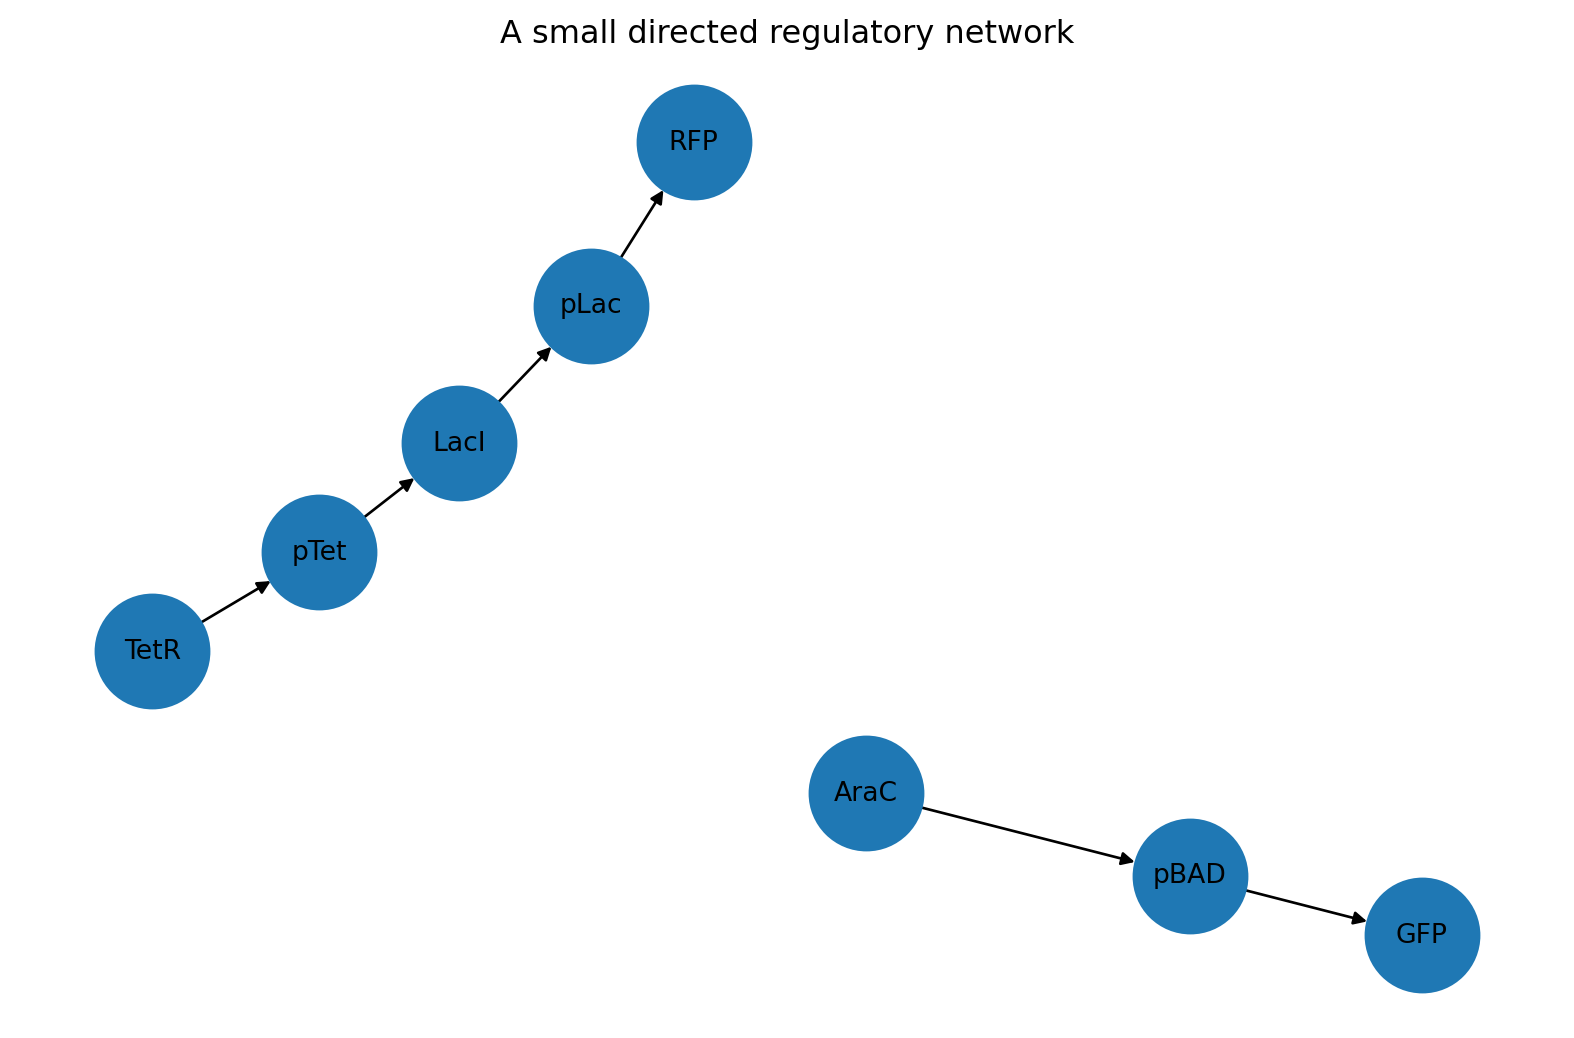

In [13]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(8, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    arrows=True,
    font_size=10,
)
plt.title("A small directed regulatory network")
plt.show()

In [14]:
for source, target, data in G.edges(data=True):
    print(f"{source} -> {target}: {data['interaction']} (sign={data['sign']})")

AraC -> pBAD: activation (sign=1)
pBAD -> GFP: expression (sign=1)
LacI -> pLac: repression (sign=-1)
pLac -> RFP: expression (sign=1)
TetR -> pTet: repression (sign=-1)
pTet -> LacI: expression (sign=1)


In [15]:
cascade_edges = pd.DataFrame(
    [
        {"source": "Input", "target": "TF1", "interaction": "activation", "sign": 1},
        {"source": "TF1", "target": "TF2", "interaction": "activation", "sign": 1},
        {"source": "TF2", "target": "Reporter", "interaction": "activation", "sign": 1},
        {"source": "TF1", "target": "Reporter", "interaction": "repression", "sign": -1},
    ]
)

cascade = nx.from_pandas_edgelist(
    cascade_edges,
    source="source",
    target="target",
    edge_attr=["interaction", "sign"],
    create_using=nx.DiGraph(),
)

list(cascade.edges(data=True))

[('Input', 'TF1', {'interaction': 'activation', 'sign': 1}),
 ('TF1', 'TF2', {'interaction': 'activation', 'sign': 1}),
 ('TF1', 'Reporter', {'interaction': 'repression', 'sign': -1}),
 ('TF2', 'Reporter', {'interaction': 'activation', 'sign': 1})]

In [16]:
nx.shortest_path(cascade, source="Input", target="Reporter")

['Input', 'TF1', 'Reporter']

In [17]:
list(nx.all_simple_paths(cascade, source="Input", target="Reporter"))

[['Input', 'TF1', 'TF2', 'Reporter'], ['Input', 'TF1', 'Reporter']]

In [18]:
def path_sign(graph, path):
    sign = 1
    for a, b in zip(path[:-1], path[1:]):
        sign *= graph.edges[a, b]["sign"]
    return sign

paths = list(nx.all_simple_paths(cascade, source="Input", target="Reporter"))

[(path, path_sign(cascade, path)) for path in paths]

[(['Input', 'TF1', 'TF2', 'Reporter'], 1), (['Input', 'TF1', 'Reporter'], -1)]

In [19]:
feedback_edges = pd.DataFrame(
    [
        {"source": "LuxR", "target": "pLux", "interaction": "activation", "sign": 1},
        {"source": "pLux", "target": "LuxI", "interaction": "expression", "sign": 1},
        {"source": "LuxI", "target": "AHL", "interaction": "synthesis", "sign": 1},
        {"source": "AHL", "target": "LuxR", "interaction": "binding_activation", "sign": 1},
    ]
)

feedback = nx.from_pandas_edgelist(
    feedback_edges,
    source="source",
    target="target",
    edge_attr=["interaction", "sign"],
    create_using=nx.DiGraph(),
)

list(nx.simple_cycles(feedback))

[['pLux', 'LuxI', 'AHL', 'LuxR']]

In [20]:
adjacency = nx.to_pandas_adjacency(cascade, dtype=int)
adjacency

,Input,TF1,TF2,Reporter
Input,0,1,0,0
TF1,0,0,1,1
TF2,0,0,0,1
Reporter,0,0,0,0


In [21]:
edge_export = nx.to_pandas_edgelist(cascade)
edge_export

,source,target,sign,interaction
0,Input,TF1,1,activation
1,TF1,TF2,1,activation
2,TF1,Reporter,-1,repression
3,TF2,Reporter,1,activation


In [22]:
dependency_table = pd.DataFrame(
    [
        {"source": "Reporter cassette", "target": "Assembled plasmid", "dependency": "required_before"},
        {"source": "Prepared backbone", "target": "Assembled plasmid", "dependency": "required_before"},
        {"source": "Assembled plasmid", "target": "Sequence verification", "dependency": "required_before"},
        {"source": "Sequence verification", "target": "Transformation", "dependency": "required_before"},
        {"source": "Transformation", "target": "Induction test", "dependency": "required_before"},
    ]
)

dependencies = nx.from_pandas_edgelist(
    dependency_table,
    source="source",
    target="target",
    edge_attr=["dependency"],
    create_using=nx.DiGraph(),
)

list(dependencies.edges(data=True))

[('Reporter cassette', 'Assembled plasmid', {'dependency': 'required_before'}),
 ('Assembled plasmid',
  'Sequence verification',
  {'dependency': 'required_before'}),
 ('Prepared backbone', 'Assembled plasmid', {'dependency': 'required_before'}),
 ('Sequence verification',
  'Transformation',
  {'dependency': 'required_before'}),
 ('Transformation', 'Induction test', {'dependency': 'required_before'})]

In [23]:
list(nx.topological_sort(dependencies))

['Reporter cassette',
 'Prepared backbone',
 'Assembled plasmid',
 'Sequence verification',
 'Transformation',
 'Induction test']

In [24]:
broken_dependency_table = pd.DataFrame(
    [
        {"source": "Assemble plasmid", "target": "Verify plasmid"},
        {"source": "Verify plasmid", "target": "Transform cells"},
        {"source": "Transform cells", "target": "Assemble plasmid"},
    ]
)

broken = nx.from_pandas_edgelist(
    broken_dependency_table,
    source="source",
    target="target",
    create_using=nx.DiGraph(),
)

nx.is_directed_acyclic_graph(broken)

False

In [25]:
degree_summary = pd.DataFrame(
    {
        "node": list(G.nodes()),
        "in_degree": [G.in_degree(node) for node in G.nodes()],
        "out_degree": [G.out_degree(node) for node in G.nodes()],
    }
)

node_summary = node_table.merge(degree_summary, on="node", how="left")
node_summary.sort_values(["kind", "node"])

,node,kind,role,in_degree,out_degree
1,pBAD,promoter,input promoter,1,1
4,pLac,promoter,regulated promoter,1,1
7,pTet,promoter,regulated promoter,1,1
0,AraC,protein,regulator,0,1
2,GFP,protein,reporter,1,0
3,LacI,protein,repressor,1,1
5,RFP,protein,reporter,1,0
6,TetR,protein,repressor,0,1
